<a href="https://colab.research.google.com/github/kartikdhoke9923/Ai-and-dl/blob/main/sequential_analaysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras import Sequential
from keras.layers import Dense, SimpleRNN, Embedding, Flatten

In [2]:
(X_train, y_train), (X_test,y_test) =imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_train=pad_sequences(X_train, padding='post', maxlen=50)
X_test=pad_sequences(X_test, padding='post', maxlen=50)

In [4]:
X_train.shape

(25000, 50)

In [5]:
model=Sequential()
model.add(Embedding(input_dim=10000, output_dim=2, input_length=50))
model.add(SimpleRNN(32, return_sequences=False))
model.add(Dense(1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
history=model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - acc: 0.6187 - loss: 0.6214 - val_acc: 0.7946 - val_loss: 0.4471
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - acc: 0.8225 - loss: 0.4002 - val_acc: 0.8028 - val_loss: 0.4275
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - acc: 0.8611 - loss: 0.3296 - val_acc: 0.8046 - val_loss: 0.4305
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - acc: 0.8839 - loss: 0.2876 - val_acc: 0.7987 - val_loss: 0.4708
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - acc: 0.9014 - loss: 0.2573 - val_acc: 0.7927 - val_loss: 0.4653
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - acc: 0.9137 - loss: 0.2277 - val_acc: 0.7941 - val_loss: 0.4965
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - acc: 0.9268 - loss: 0.2015 - val_acc: 0.7756 - val_loss: 0.6621
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - acc: 0.9380 - loss: 0.1768 - val_acc: 0.7855 - val_loss: 0.5974
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step 

In [7]:
y_pred=model.predict(X_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [15]:
y_pred_labels=(y_pred>0.5).astype(int)

In [16]:
for i in range(5):
  print('predicted: ',y_pred_labels[i], 'actual: ', y_test[i])

predicted:  [0] actual:  0
predicted:  [1] actual:  1
predicted:  [0] actual:  1
predicted:  [0] actual:  0
predicted:  [1] actual:  1


In [18]:
import numpy as np

In [19]:
y_predicted_labels=[np.argmax(i) for i in y_pred]

In [21]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred_labels)

array([[10172,  2328],
       [ 3422,  9078]])

In [28]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [29]:
cm=tf.math.confusion_matrix(labels=y_test,predictions= y_pred_labels)

Text(95.72222222222221, 0.5, 'Truth')

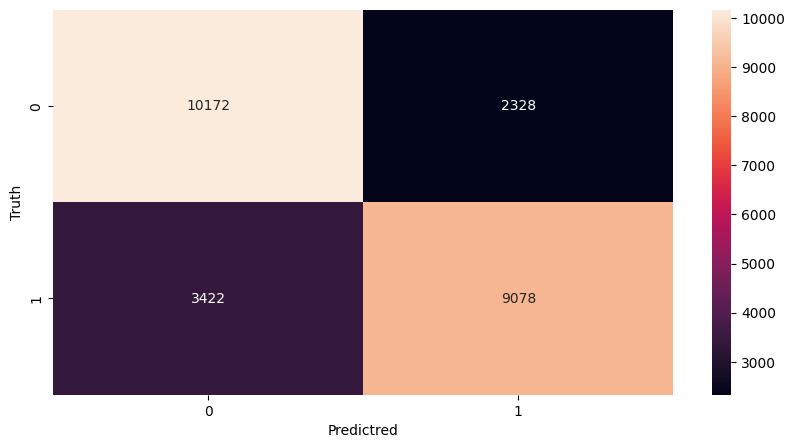

In [30]:
import seaborn as sns
plt.figure(figsize=(10,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predictred')
plt.ylabel('Truth')


[[10172  2328]
 [ 3422  9078]]


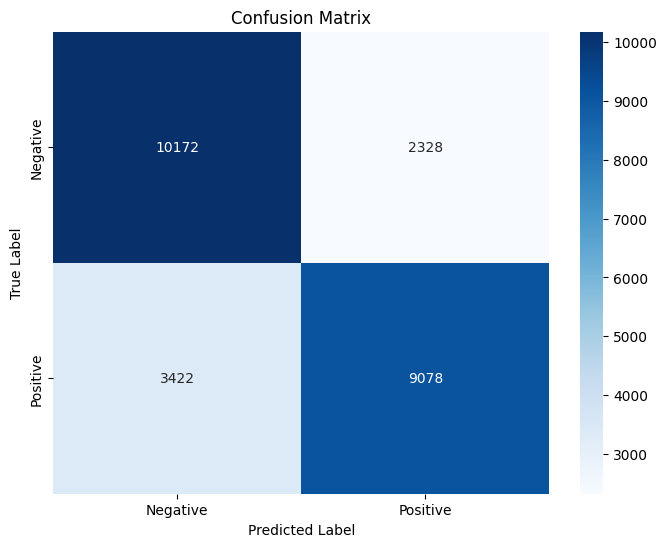

In [31]:
import seaborn as sns
cm=confusion_matrix(y_test, y_pred_labels)
print(cm)
plt.figure(figsize=(8,6))
ax=sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')
plt.show()

In [37]:
text = ['music was good story narration was excellent and acting was overacting']

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(text)

seq = tokenizer.texts_to_sequences(text)
padded = pad_sequences(seq, padding='post', maxlen=50)

prediction = model.predict(padded)
print("sentiment: ", "positive" if prediction > 0.5 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
sentiment:  positive
